# RandomForest Model Development and Evaluation Script

## Modeling Pipeline

- **Baseline Model Development:** A standard XGBoost model was trained using default hyperparameters to establish a performance benchmark.
- **Hyperparameter Optimization:** The baseline model was optimized using ***`Optuna`*** and ***`HalvingRandomSearchCV`***, enabling selection of the most effective hyperparameter configurations.
- **Cross-Validation and Robustness Assessment:** Each model variant was subjected to cross-validation to evaluate stability and generalization performance.
- **Overfitting Analysis:** A detailed comparison between cross-validation metrics and test set results was conducted. Additional metrics, including ***`RMSE ratio`*** and ***`R² gap`***, were computed to quantify overfitting and assess model generalization.

---

## Persisted Artifacts

To ensure reproducibility, transparency, and extendability, the following artifacts have been saved:

- **Optimized Model Performance:** Individual CSV files capturing the performance of each model variant:
    - ***RandomForest (Baseline)***
    - ***RandomForest (Optuna)***
    - ***RandomForest (HalvingRandomSearchCV)***

These files include detailed evaluation metrics for each variant.

- **Best Variation Performance:** A CSV file containing only the metrics of the best-performing model variation, allowing quick reference without reviewing all variants.

- **Summary of Model Performance:** A consolidated CSV file including:
    - Cross-validation results (`CV MSE`, ` MAE`, `CV RMSE`, `CV R² Score`, `CV MAPE`)
    - Test set results (`Test MSE`, `Test MAE`, `Test RMSE`, `Test R² Score`, `Test MAPE`)
    - Overfitting metrics (`R² gap`, `RMSE ratio`)
    - Overfitting status and model generalization

This file is extendable, allowing addition of new model evaluations in the future.

- **Overfitting DataFrame:** An extendable CSV specifically capturing overfitting analysis metrics across all models and variations.

- **Best Model Variation:** The serialized best-performing XGBoost model for deployment or further inference.

Together, these artifacts provide a complete, reproducible record of the modeling process, facilitating model tracking, comparison, and deployment.

## Import Libraries and Root Configuration

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
project_root = Path(os.getcwd()).parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
# records and calculations
import pandas as pd
import numpy as np

# avoid minor warnings
import warnings
warnings.filterwarnings('ignore')

# read file path
from pathlib import Path

# visualizations
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_halving_search_cv           # experimental feature
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import uniform, randint

# optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# import helper functions
from utilities import Evaluator, DataHandler, ModelPersister

## Load Dataset and Artifacts

In [3]:
df, x, y = DataHandler.load_dataset("../data/encoded_dataset.csv")
artifacts = DataHandler.load_artifacts("../artifacts/feature-selection", cv_required=True)

In [4]:
# check dataset loading
df.head()

,ItemWeight,MRP,OutletAge,Visibility,IsVisibile,IsGroceryStore,PricePerWeight,ItemType,FatContent_Regular,OutletSize_Medium,OutletSize_Small,LocationType_Tier 2,LocationType_Tier 3,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3,OutletSales
0,9.500,171.3448,26,0.034600,1,0,18.036295,7.369344,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,7.777469
1,18.000,170.5422,23,0.046381,1,0,9.474567,7.338780,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,8.040434
2,17.600,111.7202,28,0.073364,1,0,6.347739,7.294114,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,7.025718
3,8.325,41.6138,23,0.029409,1,0,4.998655,7.369344,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.650018
4,12.850,155.5630,28,0.128594,1,0,12.106070,7.372674,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,8.348656


In [5]:
# check input features
x.head()

,ItemWeight,MRP,OutletAge,Visibility,IsVisibile,IsGroceryStore,PricePerWeight,ItemType,FatContent_Regular,OutletSize_Medium,OutletSize_Small,LocationType_Tier 2,LocationType_Tier 3,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3
0,9.500,171.3448,26,0.034600,1,0,18.036295,7.369344,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,18.000,170.5422,23,0.046381,1,0,9.474567,7.338780,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,17.600,111.7202,28,0.073364,1,0,6.347739,7.294114,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,8.325,41.6138,23,0.029409,1,0,4.998655,7.369344,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,12.850,155.5630,28,0.128594,1,0,12.106070,7.372674,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [6]:
# check target feature
y.head()

0    7.777469
1    8.040434
2    7.025718
3    5.650018
4    8.348656
Name: OutletSales, dtype: float64

In [7]:
# load train/test split data
x_train, x_test, y_train, y_test = artifacts['x_train'], artifacts['x_test'], artifacts['y_train'], artifacts['y_test']
cv = artifacts['cv']

# Baseline Modeling

## Train RandomForest Model

In [8]:
# create baseline model
baseline_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# train baseline mode
baseline_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Apply Model to Make Predication

In [9]:
# baseline prediction on train and test set
y_train_pred_baseline = baseline_model.predict(x_train)
y_test_pred_baseline = baseline_model.predict(x_test)

## Evaluating Model Performance
Calculating Errors for train and test data

In [10]:
# evaluation of train metrics
train_metrics_baseline = Evaluator.calculate_metrics(y_train, y_train_pred_baseline)

# evaluation of test metrics
test_metrics_baseline = Evaluator.calculate_metrics(y_test, y_test_pred_baseline)

In [11]:
# Baseline Model Performance
baseline_perf = Evaluator.performance_table(train_metrics_baseline, test_metrics_baseline)

print("RandomForest - Baseline Modeling Performance")
display(baseline_perf)

RandomForest - Baseline Modeling Performance


,Metrics,Training,Test
0,MSE,0.0419,0.2917
1,MAE,0.1583,0.4221
2,RMSE,0.2047,0.5401
3,R2 Score,0.9593,0.7236
4,MAPE,2.2899,6.1952


# Optuna Optimzation

## Find Best Parameters

In [12]:
# define objective function
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 30),                     # prevent overfit
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.75]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0) if trial.params.get("bootstrap", True) else None,
        "random_state": 42,
        "n_jobs": -1
    }

    # Remove max_samples if bootstrap=False
    if not params["bootstrap"]:
        params.pop("max_samples", None)

    # train model with hyperparameter tuning
    model = RandomForestRegressor(**params)
    model.fit(x_train, y_train)

    # predict & evaluate on TRAIN (for speed); Optuna will rank by this
    y_pred = model.predict(x_train)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))

    return rmse

In [13]:
# enable pruning to skip bad trials early
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)

# create optuna study object
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=pruner
)

# optuna optimization with hyperparameter tuning
print("🚀 Starting Optuna optimization for Random Forest (50 trials, with pruning)...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

🚀 Starting Optuna optimization for Random Forest (50 trials, with pruning)...


Best trial: 13. Best value: 0.149277: 100%|██████████| 50/50 [07:05<00:00,  8.51s/it]


## Train optimized model

In [14]:
# Build final model (ensure max_samples handled correctly)
best_params = study.best_params.copy()
if "max_samples" in best_params and not best_params.get("bootstrap", True):
    best_params.pop("max_samples")

In [15]:
# train and fit optimized model
optuna_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
optuna_model.fit(x_train, y_train)

,n_estimators,773
,criterion,'squared_error'
,max_depth,22
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


## Apply Model to Make Predictions

In [16]:
# apply model to make predictions on train and test set
y_train_pred_optuna = optuna_model.predict(x_train)
y_test_pred_optuna = optuna_model.predict(x_test)

## Evaluating Optimized Model Performance
Calculating Errors for train and test data

In [17]:
# calculate train and test metrics
# return [mse, mae, rmse, r2, mape]
train_metrics_optuna = Evaluator.calculate_metrics(y_train, y_train_pred_optuna)
test_metrics_optuna = Evaluator.calculate_metrics(y_test, y_test_pred_optuna)

In [18]:
# performance table of optuna optimization
optuna_perf = Evaluator.performance_table(train_metrics_optuna, test_metrics_optuna)
print("RandomForest - Optuna Optimized Modeling Performance")
display(optuna_perf)

RandomForest - Optuna Optimized Modeling Performance


,Metrics,Training,Test
0,MSE,0.0223,0.2940
1,MAE,0.1141,0.4231
2,RMSE,0.1493,0.5422
3,R2 Score,0.9783,0.7214
4,MAPE,1.6493,6.2020


#  HalvingRandomSearchCV Optimzation

## Train HalvingRandomSearchCV Model

In [19]:
# parameter distribution
param_dist = {
    "max_depth": [5, 10, 15, 20, 25, 30, None],             # include None for full depth
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 11),
    "max_features": ["sqrt", "log2", 0.5, 0.75, 1.0],
    "bootstrap": [True, False],
    "max_samples": uniform(0.5, 0.5)                        # only used if bootstrap=True
}

# create HalvingRandomSearchCV model
halvingSearch = HalvingRandomSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_candidates=100,                           # start with 100 candidates
    factor=3,                                   # keep top 1/3 each iteration
    resource="n_estimators",                    # increase n_estimators over iterations
    max_resources=500,                          # max n_estimators = 500
    min_resources=50,                           # start with n_estimators = 50
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# fit the model
halvingSearch.fit(x_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'max_samples': <scipy.stats....0025B3D0AE7A0>, ...}"
,n_candidates,100
,factor,3
,resource,'n_estimators'
,max_resources,500
,min_resources,50
,aggressive_elimination,False
,cv,KFold(n_split... shuffle=True)
,scoring,'neg_root_mean_squared_error'
,refit,True


In [20]:
# find the best parameters from HalvingSearchCV
halvingSearch_model = halvingSearch.best_estimator_

# fit the best parameter
halvingSearch_model.fit(x_train, y_train)

,n_estimators,450
,criterion,'squared_error'
,max_depth,5
,min_samples_split,18
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Apply Model to Make Predictions

In [21]:
# make predictions on train and test set
y_train_pred_random = halvingSearch_model.predict(x_train)
y_test_pred_random = halvingSearch_model.predict(x_test)

## Evaluating Optimized Model Performance
Calculating Errors for train and test data

In [22]:
# calculate train and test metrics
train_metrics_random = Evaluator.calculate_metrics(y_train, y_train_pred_random)
test_metrics_random = Evaluator.calculate_metrics(y_test, y_test_pred_random)

In [23]:
# performance table of optuna optimization
random_perf = Evaluator.performance_table(train_metrics_random, test_metrics_random)

print("RandomForest - HalvingRandomSearchCV Optimized Modeling Performance")
display(random_perf)

RandomForest - HalvingRandomSearchCV Optimized Modeling Performance


,Metrics,Training,Test
0,MSE,0.2631,0.2733
1,MAE,0.3956,0.4033
2,RMSE,0.5130,0.5228
3,R2 Score,0.7441,0.7410
4,MAPE,5.7163,5.9436


# Cross Valiation (All Models)

In [24]:
# cross validation of all models
cv_baseline = Evaluator.cv_evaluate(baseline_model, x_train, y_train, cv)
cv_optuna = Evaluator.cv_evaluate(optuna_model, x_train, y_train, cv)
cv_random = Evaluator.cv_evaluate(halvingSearch_model, x_train, y_train, cv)

In [25]:
# Evaluate cross-validation results
cv_df = pd.DataFrame({
    "Model": ["RandomForest (Baseline)", "RandomForest (Optuna)", "RandomForest (HalvingRandomSearchCV)"],
    "CV MSE": [cv_baseline['CV MSE'], cv_optuna['CV MSE'], cv_random['CV MSE']],
    "CV MAE": [cv_baseline['CV MAE'], cv_optuna['CV MAE'], cv_random['CV MAE']],
    "CV RMSE": [cv_baseline['CV RMSE'], cv_optuna['CV RMSE'], cv_random['CV RMSE']],
    "CV R2": [cv_baseline['CV R2'], cv_optuna['CV R2'], cv_random['CV R2']],
    "CV MAPE": [cv_baseline['CV MAPE'], cv_optuna['CV MAPE'], cv_random['CV MAPE']]
}).round(4)

print("Cross-Validation Results:")
display(cv_df)

Cross-Validation Results:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE
0,RandomForest (Baseline),0.2979,0.4254,0.5458,0.7099,6.1563
1,RandomForest (Optuna),0.3038,0.4305,0.5512,0.7041,6.2263
2,RandomForest (HalvingRandomSearchCV),0.2762,0.4058,0.5255,0.7310,5.8882


# Summarize Models Performance

In [26]:
# selected models
models = ['RandomForest (Baseline)', 'RandomForest (Optuna)', 'RandomForest (HalvingRandomSearchCV)']

# test metrics of all models
test_metrics = [test_metrics_baseline, test_metrics_optuna, test_metrics_random]

# performance summary including cross validation results
performance_summary = Evaluator.summary_builder(models, cv_df, test_metrics)

In [27]:
# Display the final performance summary table
print("Overall Model Performance:")
display(performance_summary)

Overall Model Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE
0,RandomForest (Baseline),0.2979,0.4254,0.5458,0.7099,6.1563,0.2917,0.4221,0.5401,0.7236,6.1952
1,RandomForest (Optuna),0.3038,0.4305,0.5512,0.7041,6.2263,0.2940,0.4231,0.5422,0.7214,6.2020
2,RandomForest (HalvingRandomSearchCV),0.2762,0.4058,0.5255,0.7310,5.8882,0.2733,0.4033,0.5228,0.7410,5.9436


# Overfitting Analysis

In [28]:
# Overfitting analysis of all models

rows = []
for _, row in performance_summary.iterrows():
    # Extract metrics needed for assess_overfitting
    cv_r2 = row['CV R2']
    test_r2 = row['Test R2']
    cv_rmse = row['CV RMSE']
    test_rmse = row['Test RMSE']
    
    # get overfitting and generalization status
    gap, rmse_ratio, overfit_status, gen_status = Evaluator.assess_overfitting(
        cv_r2=cv_r2,
        test_r2=test_r2,
        cv_rmse=cv_rmse,
        test_rmse=test_rmse,
        tolerance=0.05
    )
    
    # build row
    rows.append({
        "Model": row['Model'],
        "CV RMSE": row['CV RMSE'],
        "CV R2": row['CV R2'],
        "Test RMSE": row['Test RMSE'],
        "Test R2": row['Test R2'],
        "R2 Gap": gap,
        "RMSE Ratio": rmse_ratio,
        "Overfitting Status": overfit_status,
        "Model Status (Generalization)": gen_status
    })

overfit_df = pd.DataFrame(rows).round(4)

In [29]:
print("RandomForest - Overfitting Analysis:")
display(overfit_df)

RandomForest - Overfitting Analysis:


,Model,CV RMSE,CV R2,Test RMSE,Test R2,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,RandomForest (Baseline),0.5458,0.7099,0.5401,0.7236,-0.0137,0.9896,Low,Good
1,RandomForest (Optuna),0.5512,0.7041,0.5422,0.7214,-0.0173,0.9837,Low,Good
2,RandomForest (HalvingRandomSearchCV),0.5255,0.7310,0.5228,0.7410,-0.0100,0.9949,Low,Good


# Model Comparison (Visualization)

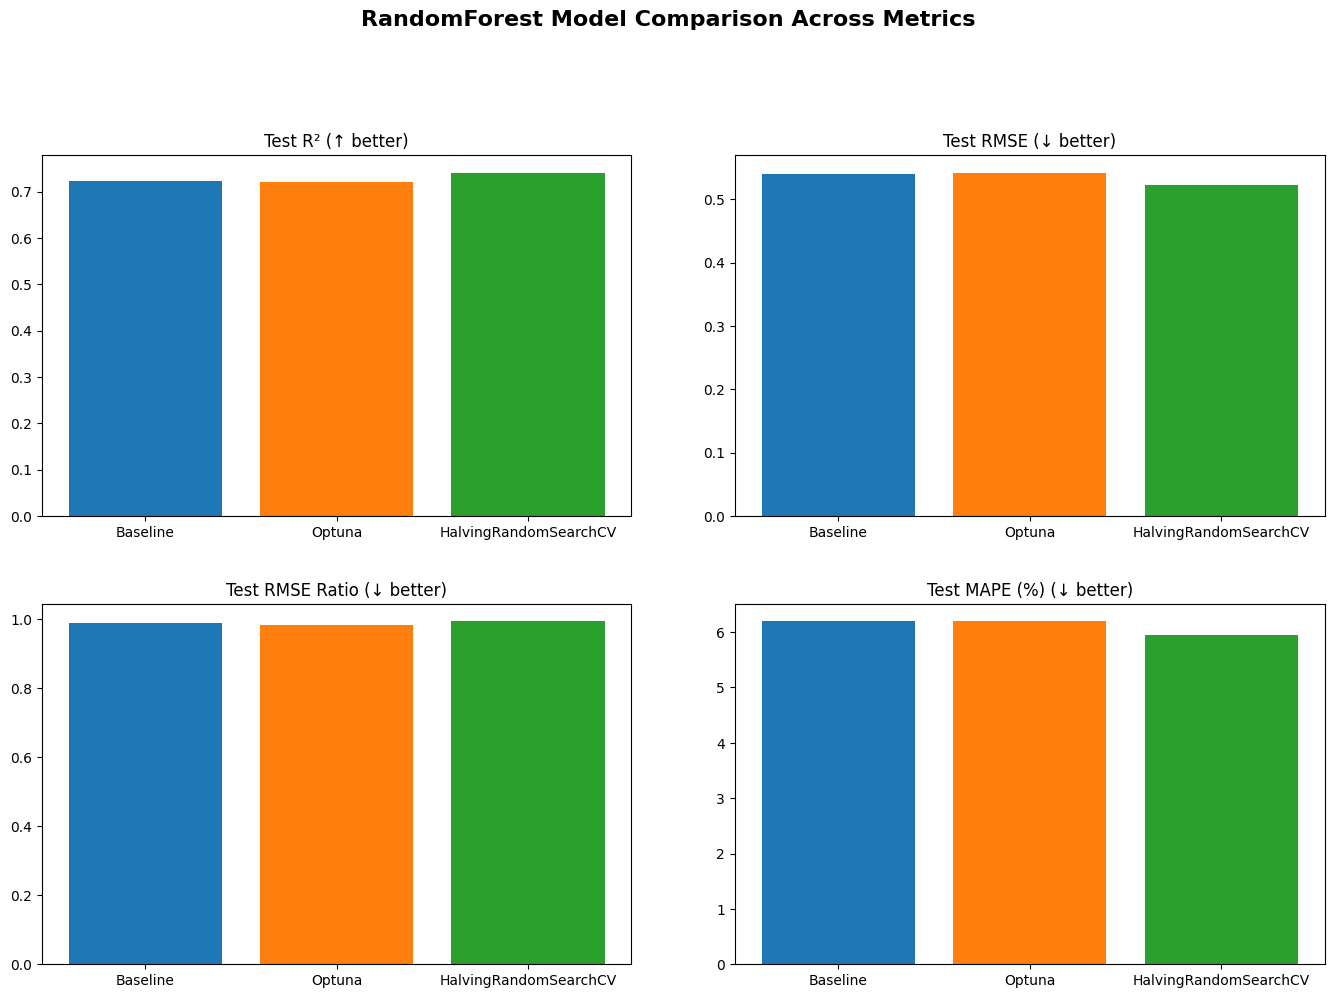

In [30]:
""" RandomForest Model Performance Comparison """

# Define metrics and titles
metrics = [
    "Test R2",
    "Test RMSE",
    "RMSE Ratio",
    "Test MAPE"
]

titles = [
    "Test R² (↑ better)",
    "Test RMSE (↓ better)",
    "Test RMSE Ratio (↓ better)",
    "Test MAPE (%) (↓ better)"
]

# Data preparation
model_labels = ["Baseline", "Optuna", "HalvingRandomSearchCV"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

values_dict = {
    "Test R2": overfit_df["Test R2"].values,
    "Test RMSE": overfit_df["Test RMSE"].values,
    "RMSE Ratio": overfit_df["RMSE Ratio"].values,
    "Test MAPE": [test_metrics_baseline[4], test_metrics_optuna[4], test_metrics_random[4]]
}

# Figure setup
n_metrics = len(metrics)
rows, cols = 2, 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes = axes.flatten()

# Plot each metric dynamically
for i, metric in enumerate(metrics):
    ax = axes[i]
    values = values_dict[metric]
    
    # Create horizontal bar chart with model-specific colors
    bars = ax.bar(model_labels, values, color=colors)
    
    # Title and labels
    ax.set_title(titles[i], fontsize=12)
    

# Hide any unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add overall title and adjust layout
plt.suptitle("RandomForest Model Comparison Across Metrics", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0, h_pad=3, w_pad=5)
plt.show()


# Final Summary of Model Performances

In [31]:
# final summary of all models performance
final_summary = pd.merge(performance_summary,
                    overfit_df[['Model', 'R2 Gap', 'RMSE Ratio', 'Overfitting Status', 'Model Status (Generalization)']],
                    on="Model",
                    how="outer")

In [32]:
print("Summary of The Models Performance:")
display(final_summary)

Summary of The Models Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,RandomForest (Baseline),0.2979,0.4254,0.5458,0.7099,6.1563,0.2917,0.4221,0.5401,0.7236,6.1952,-0.0137,0.9896,Low,Good
1,RandomForest (HalvingRandomSearchCV),0.2762,0.4058,0.5255,0.7310,5.8882,0.2733,0.4033,0.5228,0.7410,5.9436,-0.0100,0.9949,Low,Good
2,RandomForest (Optuna),0.3038,0.4305,0.5512,0.7041,6.2263,0.2940,0.4231,0.5422,0.7214,6.2020,-0.0173,0.9837,Low,Good


# Persist Best Model and Performance

In [33]:
# select best variant of XGBoost model
best_idx = final_summary["Test R2"].idxmax()
best_variant = final_summary.iloc[best_idx]

In [34]:
print("Best Variation From RandomForest Model:", best_variant["Model"])

Best Variation From RandomForest Model: RandomForest (HalvingRandomSearchCV)


In [35]:
# performance of best variation
best_variant = best_variant.to_frame(name='Value').rename_axis('Metrics').reset_index()

print("Performance of the best variation:")
display(best_variant)

Performance of the best variation:


,Metrics,Value
0,Model,RandomForest (HalvingRandomSearchCV)
1,CV MSE,0.2762
2,CV MAE,0.4058
3,CV RMSE,0.5255
4,CV R2,0.731
5,CV MAPE,5.8882
6,Test MSE,0.2733
7,Test MAE,0.4033
8,Test RMSE,0.5228
9,Test R2,0.741


In [36]:
# model persister object
persister = ModelPersister(model_name="RandomForest")

In [37]:
# persit all variatnt performance
persister.save_performance(performance_summary)

RandomForest performance saved: ..\artifacts\model-performance\randomforestPerformance.csv


In [38]:
# persist best variant performance
persister.save_performance(best_variant, "BestVariation")

RandomForest performance saved: ..\artifacts\model-performance\randomforestBestVariation.csv


In [39]:
# aggregated model performance
persister.aggregated_performance(final_summary)

Appended to aggregated performance: ..\artifacts\model-performance\a_ModelPerformance.csv


In [40]:
# save overfitting overfitting analysis
persister.append_overfitting(overfit_df)

Appended to overfitting analysis: ..\artifacts\model-performance\a_overfittingAnalysis.csv


In [41]:
# save the best variant of XGBoost model
persister.save_model(halvingSearch_model)

Model saved: ..\artifacts\models/randomforest.pkl
